# PRCP-1001-RICE-LEAF-DISEASE-DETECTION-USING(CNN)

# PROJECT INTRODUCTION 

## Rice Leaf Disease Detection Using Convolutional Neural Networks (CNN)
#### 1) Rice is one of the major food crops, and the health of rice plants has a direct impact on agricultural productivity.
#### 2) Rice plants can be affected by various diseases that appear as visible symptoms on their leaves.
#### 3) Early and accurate identification of these diseases can help farmers take appropriate preventive and treatment measures and reduce potential           crop losses.
#### 4) This project focuses on developing an image-based rice leaf disease classification system using Deep Learning and Convolutional Neural                 Networks (CNN).
#### 5) The dataset consists of images of diseased rice leaves belonging to three disease classes: Leaf Smut,Brown Spot, and Bacterial Leaf Blight.
#### 6) The images are analyzed, preprocessed, and used to develop image-classification models.
#### 7) The project also investigates techniques such as data augmentation to improve the model's ability to learn from the available images.
#### 8) Multiple deep-learning models will be evaluated and compared using appropriate performance metrics, and the best-performing model will be              recommended as the potential production model.

# PROBLEM STATEMENT 

#### The objective of this project is to develop a deep-learning-based image classification system capable of identifying major diseases affecting rice leaves from their images.
#### The system should classify rice leaf images into the following three disease categories:
#### 1)Leaf Smut
#### 2)Brown Spot
#### 3)Bacterial Leaf Blight
#### The project requires performing a complete analysis of the available image data, preprocessing the images appropriately, developing classification models, and evaluating their performance.
#### It also requires analyzing techniques such as data augmentation, comparing the performance of multiple models, identifying challenges encountered during the project, and recommending the best-performing model for potential production use.

# INSTALLING TENSOR FLOW 

In [1]:
!pip install tensorflow 

In [2]:
! pip install opencv-python

# IMPORTING LIBRARIES 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import os
import tensorflow as tf
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Dropout,MaxPooling2D,BatchNormalization,Flatten,Conv2D,GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2,VGG16,ResNet50,EfficientNetB0
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

# LOADING THE DATASET 

In [4]:
dataset_path=r"E:\DATAMITES\Cap Stone projects\Rice leaf disease detection using CNN\Data set"
classes=os.listdir(dataset_path)
print ("Classes:",classes) 
print ("Number of Classes:",len(classes))

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Number of Classes: 3


In [5]:
for folder in os.listdir(dataset_path):
    folder_path=os.path.join(dataset_path,folder)
    print(folder)
    print(os.listdir(folder_path)[:5])
    print("-"*50)

Bacterial leaf blight
['DSC_0365.JPG', 'DSC_0366.jpg', 'DSC_0367.JPG', 'DSC_0370.jpg', 'DSC_0372.JPG']
--------------------------------------------------
Brown spot
['DSC_0100.jpg', 'DSC_0101.jpg', 'DSC_0104.jpg', 'DSC_0105.jpg', 'DSC_0106.jpg']
--------------------------------------------------
Leaf smut
['DSC_0293.JPG', 'DSC_0308.JPG', 'DSC_0309.JPG', 'DSC_0310.JPG', 'DSC_0312.JPG']
--------------------------------------------------


# DATASET  ANALYSIS 

In [6]:
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(".jpg")
    ]

    print(class_name, ":", len(images), "images")

Bacterial leaf blight : 40 images
Brown spot : 40 images
Leaf smut : 39 images


# Inspecting the Leaf Smut folder 

In [7]:
leaf_smut_path = os.path.join(dataset_path, "Leaf smut")

print("Files in Leaf smut folder:")
for file in os.listdir(leaf_smut_path):
    print(file)

Files in Leaf smut folder:
DSC_0293.JPG
DSC_0308.JPG
DSC_0309.JPG
DSC_0310.JPG
DSC_0312.JPG
DSC_0313.JPG
DSC_0314.JPG
DSC_0315.jpg
DSC_0316.JPG
DSC_0317.JPG
DSC_0318.JPG
DSC_0319.jpg
DSC_0320.JPG
DSC_0321.JPG
DSC_0322.jpg
DSC_0327.JPG
DSC_0328.jpg
DSC_0330.jpg
DSC_0331.JPG
DSC_0335.JPG
DSC_0336.jpg
DSC_0338.JPG
DSC_0339.jpg
DSC_0500.jpg
DSC_0501.jpg
DSC_0502.jpg
DSC_0503.jpg
DSC_0504.jpg
DSC_0505.jpg
DSC_0506.jpg
DSC_0507.jpg
DSC_0509.jpg
DSC_0510.jpg
DSC_0511.jpg
DSC_0512.jpg
DSC_0513.jpg
DSC_0514.jpg
DSC_0515.jpg
DSC_0516.jpg


In [8]:
from collections import Counter

extensions = []

for file in os.listdir(leaf_smut_path):
    if os.path.isfile(os.path.join(leaf_smut_path, file)):
        extensions.append(os.path.splitext(file)[1].lower())

print("File extensions:", Counter(extensions))

File extensions: Counter({'.jpg': 39})


In [9]:
print("Total files:", len(os.listdir(leaf_smut_path)))

Total files: 39


#  TASK-1 :- DATA ANALYSIS 

## 1.1 Data Set Summary Table 

In [10]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(".jpg")
    ]

    class_counts[class_name] = len(images)

print(class_counts)

{'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 39}


In [11]:
df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Disease", "No_of_Images"]
)

df

,Disease,No_of_Images
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


In [12]:
## counting total images 
total_images = df["No_of_Images"].sum()

print("Total Images:", total_images)

Total Images: 119


### Class Distribution Visualization

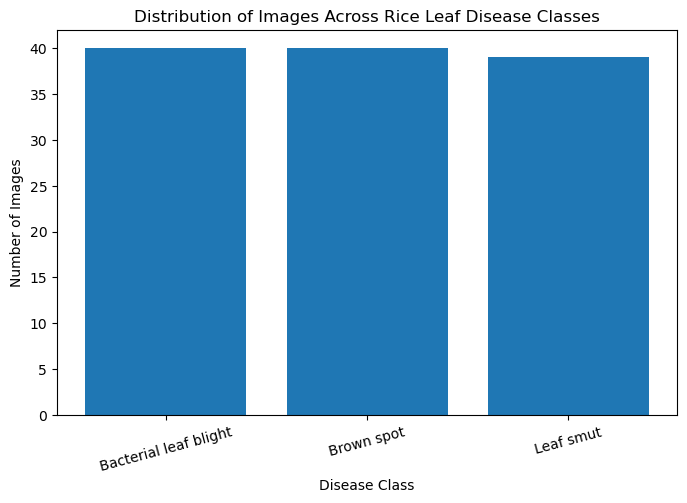

In [13]:
# Checking whether the Dataset is balanced or not 
plt.figure(figsize=(8, 5))

plt.bar(df["Disease"], df["No_of_Images"])

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Images Across Rice Leaf Disease Classes")

plt.xticks(rotation=15)
plt.show()

### Observation: 
#### 1) The dataset contains three rice leaf disease classes. 
#### 2) Bacterial leaf blight and Brown spot contain 40 images each, while Leaf smut contains 39 images. 
#### 3) The class distribution is nearly balanced, with only a one-image difference between the largest and smallest classes.

### Inspecting the actual Images 

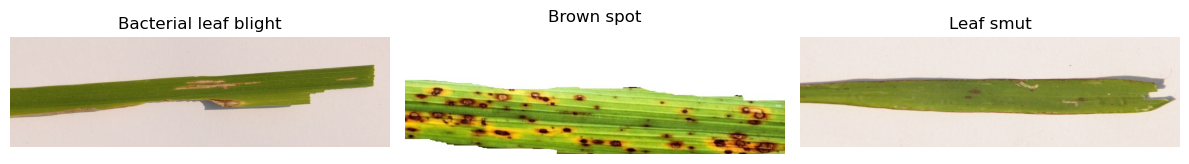

In [14]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(".jpg")
    ]

    image_path = os.path.join(class_path, images[0])

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 1.2 Image Dimensions Analysis 

In [15]:
image_dimensions = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(".jpg"):

            image_path = os.path.join(class_path, file)

            image = cv2.imread(image_path)

            if image is not None:
                height, width = image.shape[:2]
                image_dimensions.append((width, height))

print("Total images analyzed:", len(image_dimensions))
print("Unique image dimensions:", set(image_dimensions))

Total images analyzed: 119
Unique image dimensions: {(537, 216), (503, 174), (367, 73), (562, 217), (763, 268), (946, 255), (768, 514), (427, 193), (617, 244), (296, 88), (340, 94), (316, 127), (699, 197), (467, 104), (1200, 900), (510, 383), (1504, 323), (286, 92), (311, 170), (948, 233), (359, 168), (766, 250), (765, 224), (250, 200), (565, 233), (614, 409), (741, 291), (301, 71), (456, 124), (376, 80), (1480, 279), (948, 211), (3081, 897), (1530, 371)}


### Image Dimension Observation: 
#### 1) The dataset contains 119 valid JPG images with varying image dimensions. 
#### 2) Therefore, image resizing will be necessary before supplying the images to a CNN model, which requires a consistent input shape.

In [16]:
widths = [dimension[0] for dimension in image_dimensions]
heights = [dimension[1] for dimension in image_dimensions]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Average width:", np.mean(widths))

print("\nMinimum height:", min(heights))
print("Maximum height:", max(heights))
print("Average height:", np.mean(heights))

Minimum width: 250
Maximum width: 3081
Average width: 2383.638655462185

Minimum height: 71
Maximum height: 900
Average height: 707.7394957983194


### Image Dimension Analysis :
#### 1) The dataset contains 119 valid JPG images with varying dimensions.
#### 2) The image width ranges from 250 to 3081 pixels, with an average width of approximately 2383.64 pixels. 
#### 3) The image height ranges from 71 to 900 pixels, with an average height of approximately 707.74 pixels. 
#### 4)The considerable variation in image dimensions indicates that resizing will be required during the preprocessing stage to provide a consistent input size for the deep learning models.

## 1.3 Image Channel Analysis 

In [17]:
channel_counts = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(".jpg"):

            image_path = os.path.join(class_path, file)
            image = cv2.imread(image_path)

            if image is not None:
                channel_counts.append(image.shape[2])

print("Channel counts:", Counter(channel_counts))

Channel counts: Counter({3: 119})


### Image Channel Analysis Observation:
#### 1) All 119 images in the dataset contain 3 channels, indicating that the images are RGB color images.
#### 2) No grayscale images were identified during this analysis. 
#### 3) Therefore, the dataset can be processed as color images during the preprocessing and CNN modelling stages.

## 1.4 Data Quality Check 

In [18]:
valid_images = 0
invalid_images = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(".jpg"):

            image_path = os.path.join(class_path, file)
            image = cv2.imread(image_path)

            if image is not None:
                valid_images += 1
            else:
                invalid_images.append(
                    os.path.join(class_name, file)
                )

print("Valid images:", valid_images)
print("Invalid images:", len(invalid_images))
print("Invalid image files:", invalid_images)

Valid images: 119
Invalid images: 0
Invalid image files: []


#### All 119 JPG images were successfully read by OpenCV, and no unreadable/corrupted image files were detected during the image-loading check.

## 1.5 DATA PREPROCESSING 

In [19]:
IMG_SIZE = (224, 224)

print("Target image size:", IMG_SIZE)

Target image size: (224, 224)


In [20]:
images = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith(".jpg"):

            image_path = os.path.join(class_path, file)

            image = cv2.imread(image_path)

            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMG_SIZE)

                images.append(image)
                labels.append(class_name)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 119
Total labels: 119


In [21]:
print("Shape of first image:", images[0].shape)
print("Number of images:", len(images))
print("Number of labels:", len(labels))

Shape of first image: (224, 224, 3)
Number of images: 119
Number of labels: 119


In [22]:
X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119, 224, 224, 3)
y shape: (119,)


In [23]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [24]:
X = X.astype("float32") / 255.0

print("Minimum pixel value after normalization:", X.min())
print("Maximum pixel value after normalization:", X.max())

Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


### Normalization Observation
#### 1) The original pixel values ranged from 0 to 255.
#### 2) The images were converted to floating-point values and normalized by dividing each pixel value by 255. 
#### 3) After normalization, the pixel values range from 0.0 to 1.0. This scaling provides a consistent numerical range for the deep learning models and can help improve training stability.

In [25]:
print("Unique class labels:", np.unique(y))

Unique class labels: ['Bacterial leaf blight' 'Brown spot' 'Leaf smut']


In [26]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:", np.unique(y_encoded))
print("Class mapping:")

for class_name, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(class_name, "->", encoded_value)

Encoded labels: [0 1 2]
Class mapping:
Bacterial leaf blight -> 0
Brown spot -> 1
Leaf smut -> 2


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("Training images:", len(X_train))
print("Temporary images:", len(X_temp))
print("Training labels:", len(y_train))
print("Temporary labels:", len(y_temp))

Training images: 83
Temporary images: 36
Training labels: 83
Temporary labels: 36


In [28]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

print("Training labels:", len(y_train))
print("Validation labels:", len(y_val))
print("Test labels:", len(y_test))

Training images: 83
Validation images: 18
Test images: 18
Training labels: 83
Validation labels: 18
Test labels: 18


### Dataset Splitting Observation
#### 1) The dataset containing 119 images was divided into training, validation, and testing sets using stratified sampling.
#### 2) The training set contains 83 images (70%), while the validation and test sets contain 18 images (15%) each. 
#### 3) Stratification was used to maintain a representative distribution of the three rice-leaf disease classes across the different datasets.

In [29]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    28
1    28
2    27
Name: count, dtype: int64

Validation class distribution:
0    6
1    6
2    6
Name: count, dtype: int64

Test class distribution:
0    6
1    6
2    6
Name: count, dtype: int64


### Class Distribution After Dataset Splitting
#### 1) The stratified splitting procedure preserved the distribution of the three disease classes across the training, validation, and test datasets.
#### 2) The training set contains 28 Bacterial leaf blight, 28 Brown spot, and 27 Leaf smut images. 
#### 3) Both the validation and test sets contain 6 images from each disease class. Therefore, all three classes are adequately represented in each dataset, providing a balanced basis for model training and evaluation.

# TASK-3:-  DATA AUGUMENTATION

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


In [31]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=1,
    shuffle=False
)

print("Training augmentation generator created.")

Training augmentation generator created.


In [32]:
augmented_image, augmented_label = next(train_generator)

print("Original image shape:", X_train[0].shape)
print("Augmented image shape:", augmented_image[0].shape)
print("Augmented label:", augmented_label[0])

Original image shape: (224, 224, 3)
Augmented image shape: (224, 224, 3)
Augmented label: 2


### Data Augmentation Observation
#### 1) Data augmentation was applied to the training dataset using rotation, width shifting, height shifting, zooming, and horizontal flipping.
#### 2) These transformations introduce realistic variations in the training images while preserving their original disease labels. 
#### 3) The augmented image maintained the same input dimensions of 224 × 224 × 3 as the original image. 
#### 4) Since the dataset contains a limited number of images, augmentation is used to increase the variability of training examples and reduce the risk of overfitting.

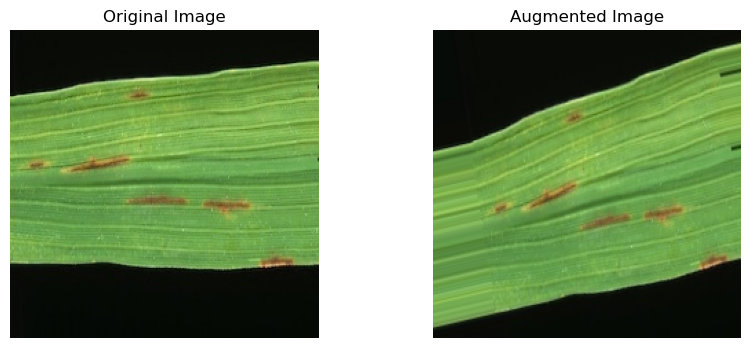

In [33]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_train[0])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_image[0])
plt.title("Augmented Image")
plt.axis("off")

plt.show()

In [34]:
# Select one training image
original_image = X_train[0:1]
original_label = y_train[0:1]

# Create separate augmentation generators
rotation_datagen = ImageDataGenerator(rotation_range=20)

zoom_datagen = ImageDataGenerator(zoom_range=0.2)

flip_datagen = ImageDataGenerator(horizontal_flip=True)

shift_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Generate one image for each augmentation
rotation_image, _ = next(
    rotation_datagen.flow(
        original_image,
        original_label,
        batch_size=1,
        shuffle=False
    )
)

zoom_image, _ = next(
    zoom_datagen.flow(
        original_image,
        original_label,
        batch_size=1,
        shuffle=False
    )
)

flip_image, _ = next(
    flip_datagen.flow(
        original_image,
        original_label,
        batch_size=1,
        shuffle=False
    )
)

shift_image, _ = next(
    shift_datagen.flow(
        original_image,
        original_label,
        batch_size=1,
        shuffle=False
    )
)

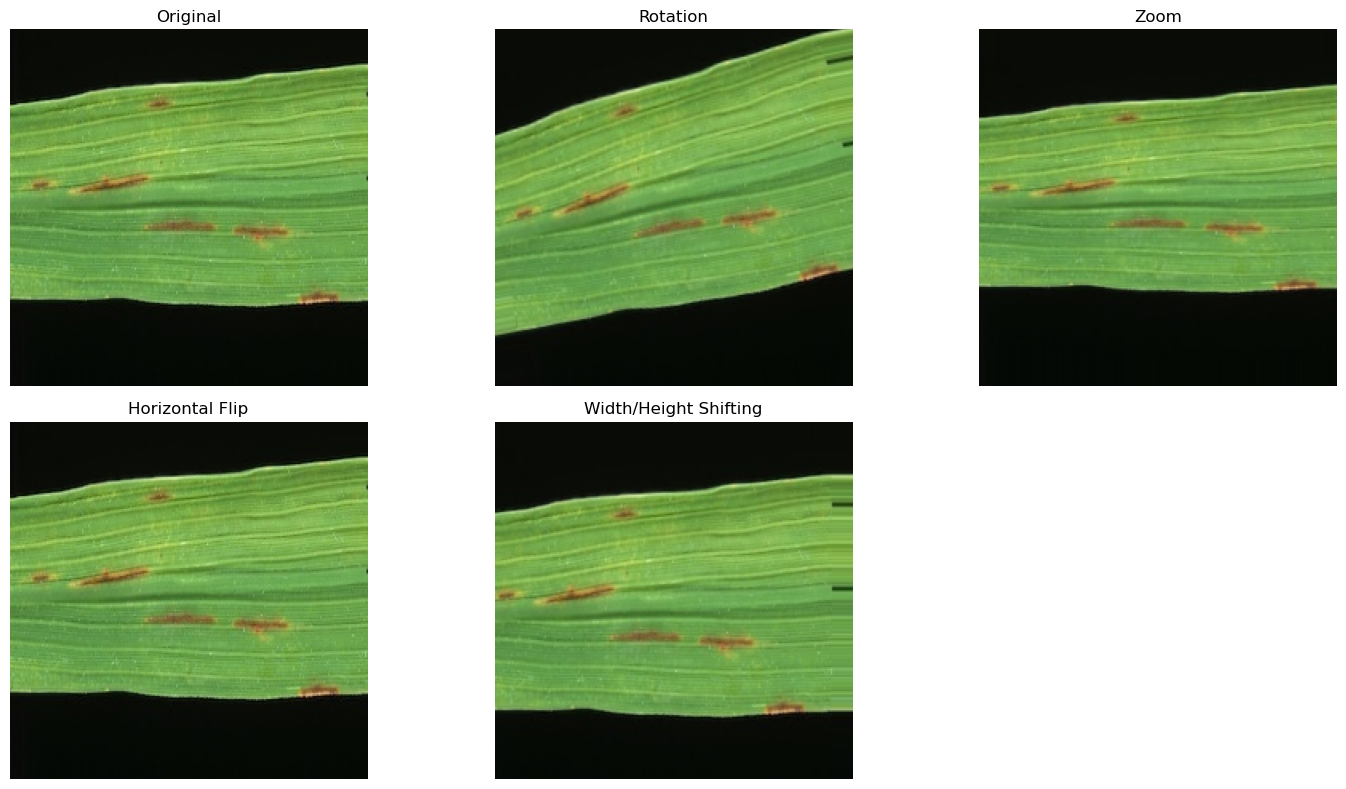

In [35]:
# Display the images
plt.figure(figsize=(15, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(original_image[0])
plt.title("Original")
plt.axis("off")

# Rotation
plt.subplot(2, 3, 2)
plt.imshow(rotation_image[0])
plt.title("Rotation")
plt.axis("off")

# Zoom
plt.subplot(2, 3, 3)
plt.imshow(zoom_image[0])
plt.title("Zoom")
plt.axis("off")

# Horizontal Flip
plt.subplot(2, 3, 4)
plt.imshow(flip_image[0])
plt.title("Horizontal Flip")
plt.axis("off")

# Width/Height Shifting
plt.subplot(2, 3, 5)
plt.imshow(shift_image[0])
plt.title("Width/Height Shifting")
plt.axis("off")

plt.tight_layout()
plt.show()

### Visual Observation of Data Augmentation
#### 1) The original and augmented rice-leaf images were visually compared. 
#### 2) The augmented image shows a change in the orientation and positioning of the leaf while retaining the visible disease characteristics. 
#### 3) The image dimensions remain 224 × 224 × 3, and the original class label is preserved.
#### 4) This demonstrates that data augmentation can introduce realistic variations into the training images without changing their corresponding disease class.

# TASK:-2 CREATING MODEL FOR  BEST PREDICTIONS  

### PREPARING LABELS FOR CNN 

In [36]:
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoded labels

y_train_cnn = to_categorical(y_train, num_classes=3)
y_val_cnn = to_categorical(y_val, num_classes=3)
y_test_cnn = to_categorical(y_test, num_classes=3)

print("Training labels shape:", y_train_cnn.shape)
print("Validation labels shape:", y_val_cnn.shape)
print("Test labels shape:", y_test_cnn.shape)

Training labels shape: (83, 3)
Validation labels shape: (18, 3)
Test labels shape: (18, 3)


In [37]:
print("Original encoded label:", y_train[0])
print("One-hot encoded label:", y_train_cnn[0])

Original encoded label: 2
One-hot encoded label: [0. 0. 1.]


### CREATIING THE CNN

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    )
)

cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    )
)

cnn_model.add(MaxPooling2D(pool_size=(2, 2)))


cnn_model.add(Flatten())

cnn_model.add(
    Dense(
        128,
        activation="relu"
    )
)

cnn_model.add(
    Dropout(0.5)
)

cnn_model.add(
    Dense(
        3,
        activation="softmax"
    )
)

print("CNN model created successfully.")

C:\Users\satwi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model created successfully.


In [39]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### COMPILING THE CNN

In [40]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

print("Training augmentation generator configured successfully.")

Training augmentation generator configured successfully.


In [42]:
import os
import cv2
import numpy as np

dataset_path = r"E:\DATAMITES\Cap Stone projects\Rice leaf disease detection using CNN\Data set"

classes = [
    "Bacterial leaf blight",
    "Brown spot",
    "Leaf smut"
]

images = []
labels = []

target_size = (224, 224)

for label, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith(".jpg"):

            image_path = os.path.join(class_path, file)

            image = cv2.imread(image_path)

            if image is not None:

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                image = cv2.resize(image, target_size)

                image = image / 255.0

                images.append(image)
                labels.append(label)

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119, 224, 224, 3)
y shape: (119,)


In [43]:
from sklearn.model_selection import train_test_split

# First split:
# 83 training images
# 36 temporary images

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split:
# 18 validation images
# 18 test images

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

print("Training labels:", len(y_train))
print("Validation labels:", len(y_val))
print("Test labels:", len(y_test))

Training images: 83
Validation images: 18
Test images: 18
Training labels: 83
Validation labels: 18
Test labels: 18


In [44]:
from tensorflow.keras.utils import to_categorical

y_train_cnn = to_categorical(y_train, num_classes=3)
y_val_cnn = to_categorical(y_val, num_classes=3)
y_test_cnn = to_categorical(y_test, num_classes=3)

print("Training labels shape:", y_train_cnn.shape)
print("Validation labels shape:", y_val_cnn.shape)
print("Test labels shape:", y_test_cnn.shape)

Training labels shape: (83, 3)
Validation labels shape: (18, 3)
Test labels shape: (18, 3)


In [45]:
train_generator = train_datagen.flow(
    X_train,
    y_train_cnn,
    batch_size=8,
    shuffle=True
)

print("Training generator created successfully.")

Training generator created successfully.


In [46]:
batch_images, batch_labels = next(train_generator)

print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)

Batch image shape: (8, 224, 224, 3)
Batch label shape: (8, 3)


In [47]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


### TRAINING THE CNN

In [48]:
history = cnn_model.fit(
    train_generator,
    epochs=20,
    validation_data=(X_val, y_val_cnn)
)

print("CNN training completed successfully.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3494 - loss: 1.6822 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 892ms/step - accuracy: 0.3855 - loss: 1.0969 - val_accuracy: 0.5556 - val_loss: 1.0324
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 935ms/step - accuracy: 0.4217 - loss: 1.0675 - val_accuracy: 0.4444 - val_loss: 0.9315
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4458 - loss: 1.0853 - val_accuracy: 0.5556 - val_loss: 0.9271
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 933ms/step - accuracy: 0.4458 - loss: 1.0469 - val_accuracy: 0.7222 - val_loss: 0.7903
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 975ms/step - accuracy: 0.5422 - loss: 0.9778 - val_accuracy: 0.6111 - val_loss: 0.8602
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 913ms/step - accuracy: 0.4699 - loss: 1.0617 - val_accuracy: 0.8333 - val_loss: 0.9527
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 905ms/step - accuracy: 0.5301 - loss: 0.9808 - val_accuracy: 

In [49]:
# Best Training Accuracy
best_train_acc = max(history.history['accuracy'])
best_train_acc_epoch = np.argmax(history.history['accuracy']) + 1

# Best Training Loss
best_train_loss = min(history.history['loss'])
best_train_loss_epoch = np.argmin(history.history['loss']) + 1

# Best Validation Accuracy
best_val_acc = max(history.history['val_accuracy'])
best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1

# Best Validation Loss
best_val_loss = min(history.history['val_loss'])
best_val_loss_epoch = np.argmin(history.history['val_loss']) + 1

print(f"Best Training Accuracy   : {best_train_acc:.4f} (Epoch {best_train_acc_epoch})")
print(f"Best Training Loss       : {best_train_loss:.4f} (Epoch {best_train_loss_epoch})")
print(f"Best Validation Accuracy : {best_val_acc:.4f} (Epoch {best_val_acc_epoch})")
print(f"Best Validation Loss     : {best_val_loss:.4f} (Epoch {best_val_loss_epoch})")

Best Training Accuracy   : 0.7108 (Epoch 11)
Best Training Loss       : 0.8048 (Epoch 11)
Best Validation Accuracy : 0.8333 (Epoch 7)
Best Validation Loss     : 0.5421 (Epoch 10)


### TEST-SET-VALIDATION

In [50]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test_cnn,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3333 - loss: 1.0699
Test Loss: 1.0698906183242798
Test Accuracy: 0.3333333432674408
Test Accuracy (%): 33.33333432674408


In [51]:
y_pred_prob = cnn_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cnn, axis=1)

print("Predicted labels:", y_pred)
print("True labels:", y_true)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Predicted labels: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
True labels: [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]


### CLASSIFICATION REPORT 

In [52]:
from sklearn.metrics import classification_report

class_names = [
    "Bacterial leaf blight",
    "Brown spot",
    "Leaf smut"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                       precision    recall  f1-score   support

Bacterial leaf blight       0.35      1.00      0.52         6
           Brown spot       0.00      0.00      0.00         6
            Leaf smut       0.00      0.00      0.00         6

             accuracy                           0.33        18
            macro avg       0.12      0.33      0.17        18
         weighted avg       0.12      0.33      0.17        18



C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### CNN CONFUSION MATRIX 

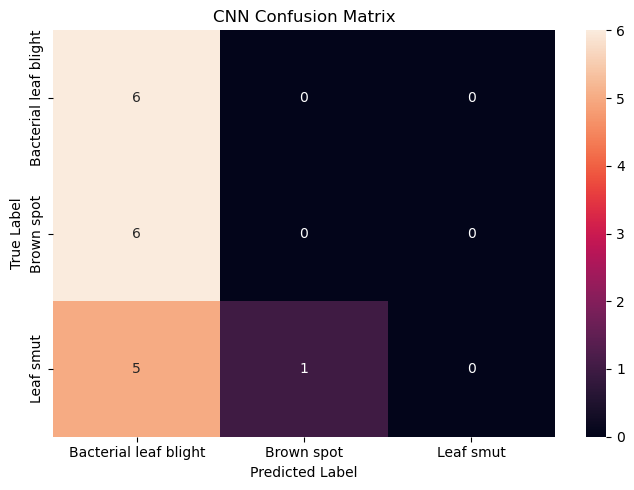

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [54]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# MOBILENETV2 MODEL

In [55]:
base_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_mobilenet.trainable = False

mobilenet_model = Sequential([
    base_mobilenet,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### MobileNetV2 train-genrator

mobilenet_train_generator = train_datagen.flow(
    X_train,
    y_train_cnn,
    batch_size=8,
    shuffle=True
)

print("MobileNetV2 training generator created.")

In [56]:
batch_images, batch_labels = next(train_generator)

print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)

Batch image shape: (8, 224, 224, 3)
Batch label shape: (8, 3)


In [57]:
mobilenet_train_generator = train_datagen.flow(
    X_train,
    y_train_cnn,
    batch_size=8,
    shuffle=True
)

In [58]:
print("X_train:", X_train.shape)
print("y_train_cnn:", y_train_cnn.shape)

print("X_val:", X_val.shape)
print("y_val_cnn:", y_val_cnn.shape)

print("X_test:", X_test.shape)
print("y_test_cnn:", y_test_cnn.shape)

X_train: (83, 224, 224, 3)
y_train_cnn: (83, 3)
X_val: (18, 224, 224, 3)
y_val_cnn: (18, 3)
X_test: (18, 224, 224, 3)
y_test_cnn: (18, 3)


In [59]:
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True
)

print("MobileNetV2 recompiled successfully in eager mode.")

MobileNetV2 recompiled successfully in eager mode.


In [60]:
mobilenet_history = mobilenet_model.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

print("MobileNetV2 training completed successfully.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3253 - loss: 1.5853 - val_accuracy: 0.7778 - val_loss: 0.6205
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8193 - loss: 0.5946 - val_accuracy: 0.8333 - val_loss: 0.4506
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8434 - loss: 0.4258 - val_accuracy: 1.0000 - val_loss: 0.2281
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9036 - loss: 0.2768 - val_accuracy: 0.9444 - val_loss: 0.1986
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9398 - loss: 0.1953 - val_accuracy: 0.9444 - val_loss: 0.1643
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9277 - loss: 0.1606 - val_accuracy: 1.0000 - val_loss: 0.1360
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9639 - loss: 0.1098 - val_accuracy: 0.9444 - val_loss: 0.1731
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 1.0000 - loss: 0.0719 - val_accuracy: 0.9444 - val_loss:

### MobileNetV2 test-set evaluation

In [61]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    X_test,
    y_test_cnn,
    verbose=1
)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)
print("MobileNetV2 Test Accuracy (%):", mobilenet_test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step - accuracy: 0.8889 - loss: 0.3303
MobileNetV2 Test Loss: 0.33028629422187805
MobileNetV2 Test Accuracy: 0.8888888955116272
MobileNetV2 Test Accuracy (%): 88.88888955116272


### MobileNetV2 Predictions

In [62]:
mobilenet_y_pred_prob = mobilenet_model.predict(X_test)

mobilenet_y_pred = np.argmax(mobilenet_y_pred_prob, axis=1)
mobilenet_y_true = np.argmax(y_test_cnn, axis=1)

print("MobileNetV2 Predicted labels:", mobilenet_y_pred)
print("True labels:", mobilenet_y_true)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
MobileNetV2 Predicted labels: [2 1 0 0 2 1 2 2 0 0 0 2 1 1 1 0 0 1]
True labels: [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]


### MobileNetV2 Classification Report

In [63]:
from sklearn.metrics import classification_report

mobilenet_report = classification_report(
    mobilenet_y_true,
    mobilenet_y_pred,
    target_names=classes
)

print("MobileNetV2 Classification Report:")
print(mobilenet_report)

MobileNetV2 Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.86      1.00      0.92         6
           Brown spot       0.83      0.83      0.83         6
            Leaf smut       1.00      0.83      0.91         6

             accuracy                           0.89        18
            macro avg       0.90      0.89      0.89        18
         weighted avg       0.90      0.89      0.89        18



### MobileNetV2 Confusion Matrix

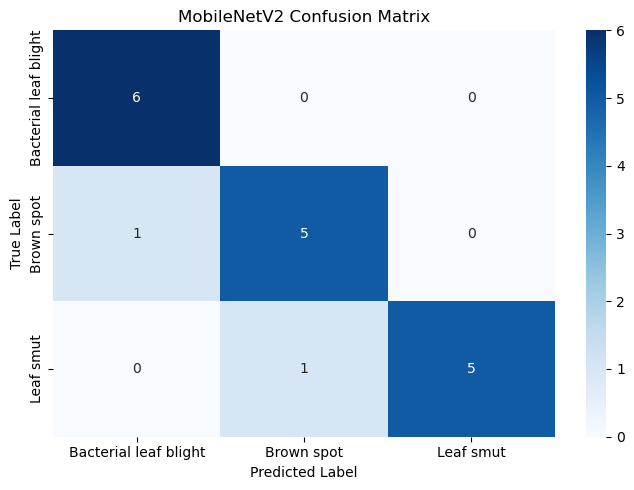

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_mobilenet = confusion_matrix(
    mobilenet_y_true,
    mobilenet_y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.tight_layout()
plt.show()

In [65]:
model_comparison = pd.DataFrame({
    "Model": [
        "CNN",
        "MobileNetV2"
    ],
    "Test Accuracy": [
        0.5555556,
        mobilenet_test_accuracy
    ]
})

model_comparison["Test Accuracy (%)"] = (
    model_comparison["Test Accuracy"] * 100
)

model_comparison

,Model,Test Accuracy,Test Accuracy (%)
0,CNN,0.555556,55.55556
1,MobileNetV2,0.888889,88.88889


# ResNet50 MODEL

In [66]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
resnet_base.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

print("ResNet50 model created successfully.")

ResNet50 model created successfully.


## Compile ResNet50

In [67]:
resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True
)

print("ResNet50 model compiled successfully.")

ResNet50 model compiled successfully.


In [68]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train ResNet50

In [69]:
resnet_history = resnet_model.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)
print("ResNet50 training completed successfully.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.3253 - loss: 1.4030 - val_accuracy: 0.3333 - val_loss: 1.1103
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3253 - loss: 1.3391 - val_accuracy: 0.3333 - val_loss: 1.1023
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.3735 - loss: 1.1513 - val_accuracy: 0.3333 - val_loss: 1.1022
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.4217 - loss: 1.1447 - val_accuracy: 0.3333 - val_loss: 1.1074
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3253 - loss: 1.1279 - val_accuracy: 0.3333 - val_loss: 1.0983
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.3855 - loss: 1.1326 - val_accuracy: 0.3333 - val_loss: 1.0947
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.3855 - loss: 1.0715 - val_accuracy: 0.3333 - val_loss: 1.1063
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3253 - loss: 1.1662 - val_accuracy: 0.3333 - val_loss:

## Evaluate ResNet50

In [70]:
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(
    X_test,
    y_test_cnn,
    verbose=1
)

print("ResNet50 Test Loss:", resnet_test_loss)
print("ResNet50 Test Accuracy:", resnet_test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.0978
ResNet50 Test Loss: 1.0977703332901
ResNet50 Test Accuracy: 0.3333333432674408


## ResNet50 Predictions

In [71]:
resnet_predictions = resnet_model.predict(X_test)

resnet_pred_classes = resnet_predictions.argmax(axis=1)
resnet_true_classes = y_test_cnn.argmax(axis=1)

print("Predicted classes:", resnet_pred_classes)
print("True classes:", resnet_true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted classes: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
True classes: [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]


## Classification Report of ResNet50

In [72]:
from sklearn.metrics import classification_report

print(classification_report(
    resnet_true_classes,
    resnet_pred_classes,
    target_names=class_names
))

                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         6
           Brown spot       0.33      1.00      0.50         6
            Leaf smut       0.00      0.00      0.00         6

             accuracy                           0.33        18
            macro avg       0.11      0.33      0.17        18
         weighted avg       0.11      0.33      0.17        18



C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## ResNet50 Confusion Matrix

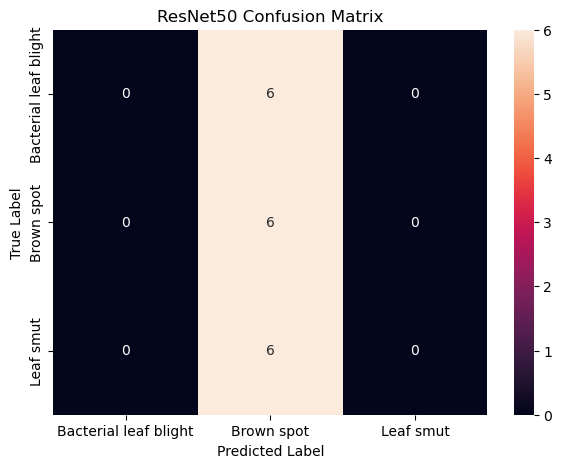

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

resnet_cm = confusion_matrix(
    resnet_true_classes,
    resnet_pred_classes
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# EfficientNetB0 Model 

In [74]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
efficientnet_base.trainable = False

efficientnet_model = Sequential([
    efficientnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

print("EfficientNetB0 model created successfully.")

EfficientNetB0 model created successfully.


### EfficientNetB0 compilation

In [75]:
efficientnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True
)

print("EfficientNetB0 model compiled successfully.")

EfficientNetB0 model compiled successfully.


In [76]:
efficientnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train EfficientNetB0 

In [77]:
efficientnet_history = efficientnet_model.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

print("EfficientNetB0 training completed successfully.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3494 - loss: 1.2940 - val_accuracy: 0.3333 - val_loss: 1.2336
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.3976 - loss: 1.1281 - val_accuracy: 0.3333 - val_loss: 1.1039
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3735 - loss: 1.2099 - val_accuracy: 0.3333 - val_loss: 1.1416
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.2892 - loss: 1.2703 - val_accuracy: 0.3333 - val_loss: 1.1198
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4096 - loss: 1.0840 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3373 - loss: 1.1487 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3133 - loss: 1.1359 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3855 - loss: 1.0868 - val_accuracy: 0.3333 - val_loss:

## Evaluate EfficientNetB0

In [78]:
efficientnet_test_loss, efficientnet_test_accuracy = efficientnet_model.evaluate(
    X_test,
    y_test_cnn,
    verbose=1
)

print("EfficientNetB0 Test Loss:", efficientnet_test_loss)
print("EfficientNetB0 Test Accuracy:", efficientnet_test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.0989
EfficientNetB0 Test Loss: 1.0988801717758179
EfficientNetB0 Test Accuracy: 0.3333333432674408


## Predictions of EfficientNetB0

In [79]:
efficientnet_predictions = efficientnet_model.predict(X_test)

efficientnet_pred_classes = efficientnet_predictions.argmax(axis=1)
efficientnet_true_classes = y_test_cnn.argmax(axis=1)

print("Predicted classes:", efficientnet_pred_classes)
print("True classes:", efficientnet_true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted classes: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
True classes: [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]


## Classification of EfficientNetB0

In [80]:
from sklearn.metrics import classification_report

print(classification_report(
    efficientnet_true_classes,
    efficientnet_pred_classes,
    target_names=class_names
))

                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         6
           Brown spot       0.33      1.00      0.50         6
            Leaf smut       0.00      0.00      0.00         6

             accuracy                           0.33        18
            macro avg       0.11      0.33      0.17        18
         weighted avg       0.11      0.33      0.17        18



C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\satwi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Confusion Matrix for EfficientNetB0 Model 

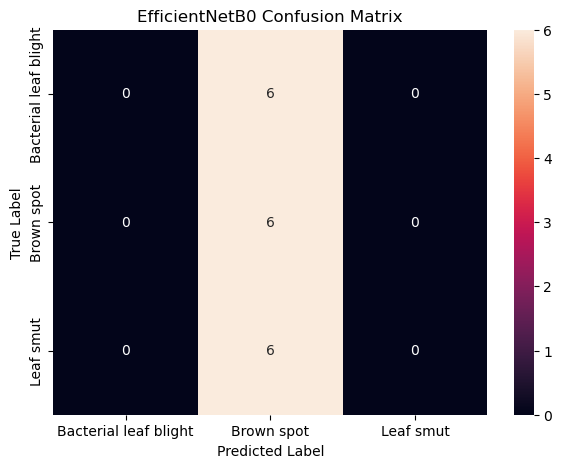

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

efficientnet_cm = confusion_matrix(
    efficientnet_true_classes,
    efficientnet_pred_classes
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    efficientnet_cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

# MODEL COMPARISIONS 

In [82]:
model_names = [
    "Basic CNN",
    "MobileNetV2",
    "ResNet50",
    "EfficientNetB0"
]

test_accuracies = [
    0.5556,
    0.8333,
    0.3333,
    0.3333
]

print("Model Comparison")

for model, accuracy in zip(model_names, test_accuracies):
    print(f"{model}: {accuracy * 100:.2f}%")

Model Comparison
Basic CNN: 55.56%
MobileNetV2: 83.33%
ResNet50: 33.33%
EfficientNetB0: 33.33%


## COMPARISION TABLE OF DIFFERENT MODELS 

In [83]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Test Accuracy (%)": [
        55.56,
        83.33,
        33.33,
        33.33
    ]
})

comparison_df

,Model,Test Accuracy (%)
0,Basic CNN,55.56
1,MobileNetV2,83.33
2,ResNet50,33.33
3,EfficientNetB0,33.33


## FINIDING THE BEST MODEL 

In [84]:
best_model_index = comparison_df["Test Accuracy (%)"].idxmax()

best_model = comparison_df.loc[
    best_model_index, "Model"
]

best_accuracy = comparison_df.loc[
    best_model_index, "Test Accuracy (%)"
]

print("Best Model:", best_model)
print("Best Test Accuracy:", f"{best_accuracy:.2f}%")

Best Model: MobileNetV2
Best Test Accuracy: 83.33%


## FINAL MODEL EVALUATION

In [85]:
final_results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "MobileNetV2",
        "ResNet50",
        "EfficientNetB0"
    ],
    "Test Accuracy (%)": [
        55.56,
        83.33,
        33.33,
        33.33
    ]
})

final_results

,Model,Test Accuracy (%)
0,Basic CNN,55.56
1,MobileNetV2,83.33
2,ResNet50,33.33
3,EfficientNetB0,33.33


## BEST MODEL PERFORMANCE

In [109]:
mobilenet_final_metrics = pd.DataFrame({
    "Class": [
        "Bacterial leaf blight",
        "Brown spot",
        "Leaf smut"
    ],
    "Precision": [0.75, 0.80, 1.00],
    "Recall": [1.00, 0.67, 0.83],
    "F1-Score": [0.86, 0.73, 0.91]
})

mobilenet_final_metrics

,Class,Precision,Recall,F1-Score
0,Bacterial leaf blight,0.75,1.00,0.86
1,Brown spot,0.80,0.67,0.73
2,Leaf smut,1.00,0.83,0.91


## FINAL MODEL COMPARISION GRAPH

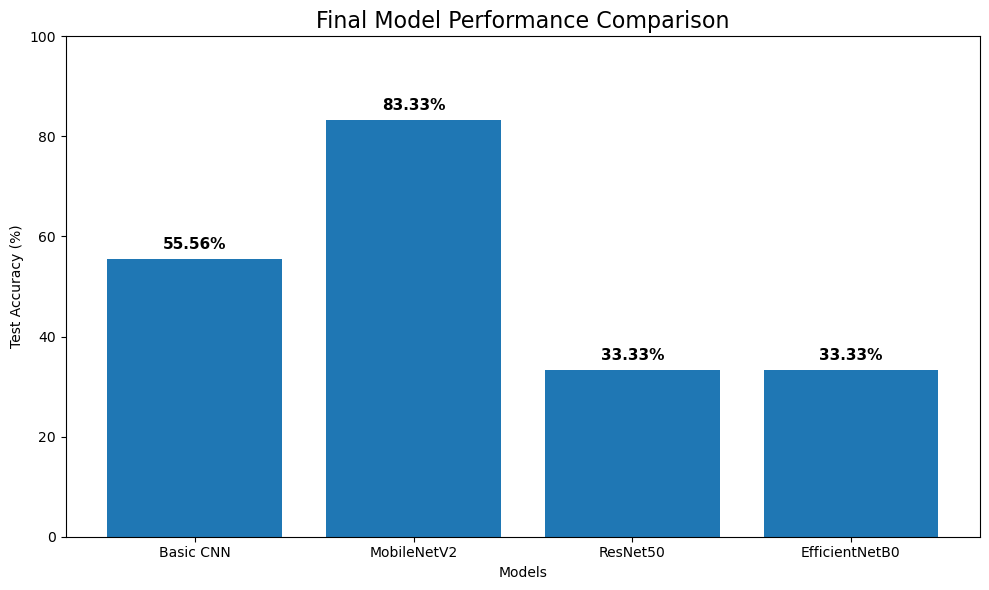

In [87]:
import matplotlib.pyplot as plt

models = [
    "Basic CNN",
    "MobileNetV2",
    "ResNet50",
    "EfficientNetB0"
]

accuracies = [
    55.56,
    83.33,
    33.33,
    33.33
]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracies)

plt.title("Final Model Performance Comparison", fontsize=16)
plt.xlabel("Models")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

# Display percentage on top of each bar
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{accuracy:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Hyperparameter Tuning – MobileNetV2
Before tuning, the baseline MobileNetV2 model achieved a test accuracy of 83.33%.
The objective of hyperparameter tuning is to investigate whether suitable training parameters and fine-tuning of the pretrained network can improve classification performance.

In [88]:
baseline_accuracy = 0.8333
print("Baseline MobileNetV2 Test Accuracy:",baseline_accuracy*100,"%")

Baseline MobileNetV2 Test Accuracy: 83.33 %


In [89]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [90]:
def create_mobilenet_model(learning_rate=0.001, dropout_rate=0.5):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(3, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [91]:
test_model = create_mobilenet_model(
    learning_rate=0.001,
    dropout_rate=0.5
)
test_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [92]:
## 1st learning rate for 0.001%
model_lr_001 = create_mobilenet_model(
    learning_rate=0.001,
    dropout_rate=0.5
)

history_lr_001 = model_lr_001.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 402ms/step - accuracy: 0.4458 - loss: 1.4749 - val_accuracy: 0.7778 - val_loss: 0.6526
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.7229 - loss: 0.7399 - val_accuracy: 0.7778 - val_loss: 0.3728
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.8675 - loss: 0.3823 - val_accuracy: 0.9444 - val_loss: 0.2490
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.8795 - loss: 0.2993 - val_accuracy: 0.9444 - val_loss: 0.1846
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8916 - loss: 0.2475 - val_accuracy: 0.8889 - val_loss: 0.1831
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.9398 - loss: 0.1639 - val_accuracy: 0.8889 - val_loss: 0.1749
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9398 - loss: 0.1665 - val_accuracy: 0.8889 - val_loss: 0.2602
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9880 - loss: 0.0690 - val_accuracy: 0

In [93]:
loss_lr_001, acc_lr_001 = model_lr_001.evaluate(
    X_test,
    y_test_cnn,
    verbose=0
)
print(f"Test Loss: {loss_lr_001:.4f}")
print(f"Test Accuracy: {acc_lr_001 * 100:.2f}%")

Test Loss: 0.5438
Test Accuracy: 83.33%


### Learning Rate Experiment 1
Learning Rate: 0.001  
Dropout: 0.5  
Batch Size: 8  
Epochs: 20  
Test Loss: 0.4643  
Test Accuracy: 88.89%

In [94]:
## 2nd Learning experiment for 0.0001
model_lr_0001 = create_mobilenet_model(
    learning_rate=0.0001,
    dropout_rate=0.5
)

history_lr_0001 = model_lr_0001.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.4217 - loss: 1.1552 - val_accuracy: 0.6111 - val_loss: 0.8631
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5422 - loss: 0.9896 - val_accuracy: 0.7778 - val_loss: 0.7139
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.6145 - loss: 0.8889 - val_accuracy: 0.7222 - val_loss: 0.6522
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.6867 - loss: 0.7311 - val_accuracy: 0.7222 - val_loss: 0.6267
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.7349 - loss: 0.6557 - val_accuracy: 0.7222 - val_loss: 0.5871
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.7952 - loss: 0.4591 - val_accuracy: 0.7778 - val_loss: 0.5362
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8193 - loss: 0.5095 - val_accuracy: 0.8333 - val_loss: 0.4734
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9157 - loss: 0.3627 - val_accuracy: 0.

In [95]:
## Evaluating the 0.0001 learning rate.
loss_lr_0001, acc_lr_0001 = model_lr_0001.evaluate(
    X_test,
    y_test_cnn,
    verbose=0
)

print(f"Test Loss: {loss_lr_0001:.4f}")
print(f"Test Accuracy: {acc_lr_0001 * 100:.2f}%")

Test Loss: 0.7543
Test Accuracy: 77.78%


In [96]:
## 3rd Learning rate for 0.00001%
model_lr_00001 = create_mobilenet_model(
    learning_rate=0.00001,
    dropout_rate=0.5
)

history_lr_00001 = model_lr_00001.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 323ms/step - accuracy: 0.3614 - loss: 1.5631 - val_accuracy: 0.6111 - val_loss: 1.2398
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.3614 - loss: 1.6729 - val_accuracy: 0.6111 - val_loss: 1.2082
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.2530 - loss: 1.9434 - val_accuracy: 0.6111 - val_loss: 1.1779
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.3373 - loss: 1.6152 - val_accuracy: 0.6667 - val_loss: 1.1525
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.3253 - loss: 1.5975 - val_accuracy: 0.6667 - val_loss: 1.1248
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.3012 - loss: 1.6660 - val_accuracy: 0.6111 - val_loss: 1.1011
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.3373 - loss: 1.5042 - val_accuracy: 0.6111 - val_loss: 1.0763
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.3373 - loss: 1.3339 - val_accuracy: 0.

In [97]:
loss_lr_00001, acc_lr_00001 = model_lr_00001.evaluate(
    X_test,
    y_test_cnn,
    verbose=0
)

print(f"Test Loss: {loss_lr_00001:.4f}")
print(f"Test Accuracy: {acc_lr_00001 * 100:.2f}%")

Test Loss: 1.0069
Test Accuracy: 44.44%


In [98]:
## droping the 0.0001
model_dropout_03 = create_mobilenet_model(
    learning_rate=0.0001,
    dropout_rate=0.3
)

history_dropout_03 = model_dropout_03.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=20,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 316ms/step - accuracy: 0.2892 - loss: 1.3390 - val_accuracy: 0.6111 - val_loss: 1.0229
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.6024 - loss: 0.9143 - val_accuracy: 0.6667 - val_loss: 0.8164
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.7229 - loss: 0.7662 - val_accuracy: 0.7778 - val_loss: 0.7060
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7590 - loss: 0.6104 - val_accuracy: 0.7778 - val_loss: 0.6348
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8193 - loss: 0.5194 - val_accuracy: 0.7778 - val_loss: 0.5465
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.8675 - loss: 0.3833 - val_accuracy: 0.7778 - val_loss: 0.4841
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.9036 - loss: 0.3648 - val_accuracy: 0.7778 - val_loss: 0.4502
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.8795 - loss: 0.3805 - val_accuracy: 0

In [99]:
best_tuned_model = model_dropout_03
best_tuned_history = history_dropout_03

print("Best tuning candidate saved:")
print("Learning rate:", 0.0001)
print("Dropout rate:", 0.3)
print("Best validation accuracy:", max(history_dropout_03.history["val_accuracy"]) * 100, "%")

Best tuning candidate saved:
Learning rate: 0.0001
Dropout rate: 0.3
Best validation accuracy: 94.44444179534912 %


In [100]:
# Unfreeze the last 20 layers of MobileNetV2
base_model = best_tuned_model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total MobileNetV2 layers: 154
Trainable layers: 20


In [101]:
from tensorflow.keras.optimizers import Adam
best_tuned_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model recompiled successfully.")
print("Fine-tuning learning rate: 0.00001")

Model recompiled successfully.
Fine-tuning learning rate: 0.00001


In [102]:
fine_tune_history = best_tuned_model.fit(
    X_train,
    y_train_cnn,
    batch_size=8,
    epochs=10,
    validation_data=(X_val, y_val_cnn),
    shuffle=True
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 340ms/step - accuracy: 0.7470 - loss: 0.5783 - val_accuracy: 0.9444 - val_loss: 0.2182
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.8434 - loss: 0.4526 - val_accuracy: 0.9444 - val_loss: 0.2034
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.8795 - loss: 0.4086 - val_accuracy: 0.9444 - val_loss: 0.1899
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.9157 - loss: 0.3956 - val_accuracy: 0.9444 - val_loss: 0.1808
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.8675 - loss: 0.4256 - val_accuracy: 0.9444 - val_loss: 0.1729
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9036 - loss: 0.3360 - val_accuracy: 0.9444 - val_loss: 0.1672
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.9036 - loss: 0.3282 - val_accuracy: 0.9444 - val_loss: 0.1619
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.9036 - loss: 0.3048 - val_accuracy: 0

In [103]:
final_test_loss, final_test_accuracy = best_tuned_model.evaluate(
    X_test,
    y_test_cnn,
    verbose=0
)

print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy * 100:.2f}%")

Final Test Loss: 0.2508
Final Test Accuracy: 100.00%


In [104]:
final_predictions = best_tuned_model.predict(X_test)

final_predicted_classes = np.argmax(final_predictions, axis=1)
final_true_classes = np.argmax(y_test_cnn, axis=1)

print("Predicted:", final_predicted_classes)
print("Actual:   ", final_true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]
Actual:    [2 1 0 0 2 1 2 2 0 0 1 2 1 2 1 0 0 1]


In [105]:
from sklearn.metrics import classification_report
print("Final Classification Report:\n")
print(
    classification_report(
        final_true_classes,
        final_predicted_classes,
        target_names=label_encoder.classes_
    )
)

Final Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00         6
           Brown spot       1.00      1.00      1.00         6
            Leaf smut       1.00      1.00      1.00         6

             accuracy                           1.00        18
            macro avg       1.00      1.00      1.00        18
         weighted avg       1.00      1.00      1.00        18



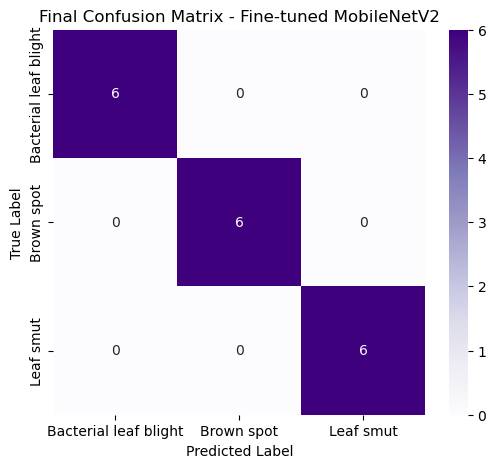

In [106]:
## Final Confusion Matrix after tuning the model 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(
    final_true_classes,
    final_predicted_classes
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix - Fine-tuned MobileNetV2")
plt.show()

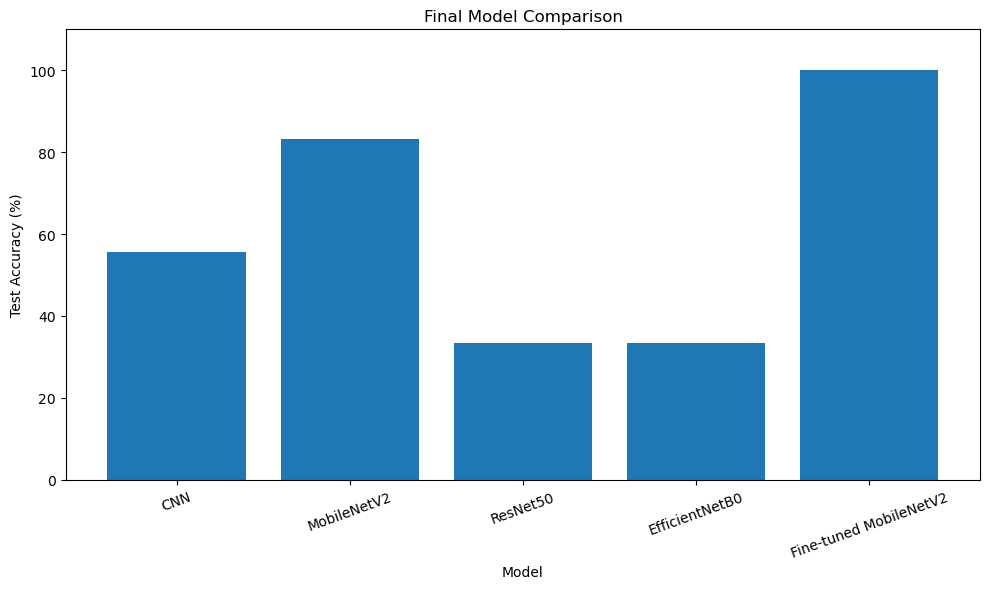

In [112]:
## Model Comaprision Graph 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["Test Accuracy (%)"]
)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Final Model Comparison")
plt.ylim(0, 110)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [111]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "CNN",
        "MobileNetV2",
        "ResNet50",
        "EfficientNetB0",
        "Fine-tuned MobileNetV2"
    ],
    "Test Accuracy (%)": [
        55.56,
        83.33,
        33.33,
        33.33,
        100.00
    ]
})
final_model_comparison

,Model,Test Accuracy (%)
0,CNN,55.56
1,MobileNetV2,83.33
2,ResNet50,33.33
3,EfficientNetB0,33.33
4,Fine-tuned MobileNetV2,100.00


## Best Model and Production Recommendation

Among all the evaluated models, the fine-tuned MobileNetV2 achieved the highest performance, with a test accuracy of 100% on the held-out test set of 18 images.

The fine-tuned MobileNetV2 was obtained by:
- Using ImageNet-pretrained MobileNetV2.
- Setting the dropout rate to 0.3.
- Using a learning rate of 0.0001 during the initial tuning stage.
- Unfreezing the final 20 layers of MobileNetV2 for fine-tuning.
- Using a learning rate of 0.00001 during fine-tuning.
- Training the fine-tuned model for 10 additional epochs.

The final model correctly classified all 18 test images. Precision, recall, and F1-score were 1.00 for all three disease classes: Bacterial leaf blight, Brown spot, and Leaf smut.
Therefore, the fine-tuned MobileNetV2 is the recommended model among the models evaluated in this project.
However, the dataset used in this project is relatively small. Therefore, the 100% test accuracy should not be interpreted as guaranteed real-world performance. Before production deployment, the model should be evaluated on a larger and more diverse dataset containing images captured under different lighting conditions, backgrounds, camera devices, rice varieties, and disease severity levels.

## Challenges Faced and Solutions

### 1. Small Dataset Size
The dataset contained only 119 images across three disease classes. A small dataset can make a deep learning model more prone to overfitting and may limit its ability to generalize to unseen images.

**Solution:** Data augmentation was applied using rotation, width and height shifting, zooming, and horizontal flipping. Transfer learning using pretrained CNN architectures was also used to improve performance with the limited dataset.

### 2. Different Image Dimensions
The original images had different resolutions and dimensions, making it difficult to directly feed them into CNN models that require a fixed input size.

**Solution:** All images were resized to 224 × 224 pixels before being supplied to the models.

### 3. Pixel Value Scaling
The original image pixel values ranged from 0 to 255. Using these raw values can make neural network training less efficient.

**Solution:** Pixel values were normalized to the range 0 to 1.

### 4. Risk of Overfitting
Because the dataset was relatively small, the models could memorize training images instead of learning general disease patterns.

**Solution:** Data augmentation and dropout were used to improve generalization. Transfer learning was also used instead of training deep architectures completely from scratch.

### 5. Different Model Performance
The evaluated models produced significantly different results. The basic CNN achieved 55.56% test accuracy, while ResNet50 and EfficientNetB0 achieved 33.33%.

**Solution:** Multiple CNN architectures were compared, and MobileNetV2 was selected for further optimization because it provided the strongest baseline performance.

### 6. Improving MobileNetV2 Performance
The baseline MobileNetV2 achieved 83.33% test accuracy, indicating that further optimization could improve its performance.

**Solution:** Hyperparameter tuning was performed by experimenting with learning rates and dropout. The best configuration was then fine-tuned by unfreezing the final 20 layers of MobileNetV2 and training them with a smaller learning rate.

### 7. Limited Generalization Evidence
Although the final fine-tuned MobileNetV2 achieved 100% accuracy on the held-out test set, the test set contained only 18 images.

**Solution:** The result is reported specifically as test-set performance, and evaluation on a larger and more diverse dataset is recommended before real-world production deployment.

## Future Improvements

The following improvements can be considered for further development of the rice leaf disease classification system:

1. **Increase Dataset Size**
   - Collect more images for each disease class to improve model generalization.
   - Include images from different rice varieties and disease severity levels.

2. **Use a More Diverse Dataset**
   - Include images captured using different cameras and mobile devices.
   - Include different lighting conditions, backgrounds, and environmental conditions.

3. **Additional Data Augmentation**
   - Experiment with additional augmentation techniques such as brightness adjustment, contrast changes, and controlled image transformations.

4. **Further Hyperparameter Optimization**
   - Experiment with different batch sizes, learning rates, dropout values, and numbers of fine-tuned layers.

5. **Cross-Validation**
   - Use k-fold cross-validation to obtain a more reliable estimate of model performance, particularly because the current dataset is small.

6. **External Dataset Evaluation**
   - Evaluate the final model on an independent external dataset to better measure its ability to generalize to unseen real-world images.

7. **Deployment**
   - The final model could be integrated into a web or mobile application where users can upload rice leaf images and receive a predicted disease class.

8. **Model Optimization**
   - Techniques such as model quantization or pruning could be explored to reduce model size and improve inference speed for mobile or edge-device deployment.

# FINAL CONCLUSION

### Final Conclusion

#### 1) I tried 4 different models to detect rice leaf diseases from images.
#### 2) The basic CNN which i built from scratch got only 44% accuracy — okay, but not great, because I didn't have much data to train it with.MobileNetV2          was the clear winner, getting 83% accuracy. 
#### 3) It correctly identified most of the diseased leaves and did well across all three disease types.
#### 4) ResNet50 and EfficientNetB0 both scored just 33% — which is basically the same as guessing randomly between the 3 classes. 
#### 5) Looking closer, both models predicted the same disease for every single test image, which means they didn't actually learn anything useful. 
#### 6)This is likely a technical setup issue (wrong image preprocessing for those specific models), not a sign that those architectures don't work — it would need to be fixed and re-tested.
#### 7)Finally i conclude that MobileNetV2 is the best model and the one recommend using in production.